In [44]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns



In [45]:
df = pd.read_csv("../data/Forecasting Case- Study.xlsx - Sheet1.csv")

In [46]:
df.head()

,State,Date,Total,Category
0,Alabama,1/12/2019,"109,574,036",Beverages
1,Arizona,1/12/2019,"109,101,595",Beverages
2,Arkansas,1/12/2019,"58,049,432",Beverages
3,California,1/12/2019,"444,766,891",Beverages
4,Colorado,1/12/2019,"89,816,716",Beverages


In [47]:
df.shape

(8084, 4)

In [48]:
df.isnull().sum()

State       0
Date        0
Total       0
Category    0
dtype: int64

In [49]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, format='mixed')

In [50]:
df.head()

,State,Date,Total,Category
0,Alabama,2019-12-01,"109,574,036",Beverages
1,Arizona,2019-12-01,"109,101,595",Beverages
2,Arkansas,2019-12-01,"58,049,432",Beverages
3,California,2019-12-01,"444,766,891",Beverages
4,Colorado,2019-12-01,"89,816,716",Beverages


In [51]:
df = df.sort_values('Date')

In [52]:
df = df.reset_index(drop=True)

In [53]:
df

,State,Date,Total,Category
0,Iowa,2019-10-06,"63,444,415",Beverages
1,Minnesota,2019-10-06,"86,019,275",Beverages
2,Michigan,2019-10-06,"162,440,135",Beverages
3,Massachusetts,2019-10-06,"102,038,881",Beverages
4,Maryland,2019-10-06,"97,008,034",Beverages
...,...,...,...,...
8079,Maine,2023-05-07,"49,205,689",Beverages
8080,Maryland,2023-05-07,"160,481,700",Beverages
8081,Massachusetts,2023-05-07,"189,283,132",Beverages
8082,Minnesota,2023-05-07,"168,499,755",Beverages


In [54]:
df["Category"].unique()

<StringArray>
['Beverages']
Length: 1, dtype: str

In [55]:
df["State"].unique()

<StringArray>
[          'Iowa',      'Minnesota',       'Michigan',  'Massachusetts',
       'Maryland',          'Maine',      'Louisiana',       'Kentucky',
         'Kansas',    'Mississippi',        'Indiana',        'Georgia',
        'Florida',    'Connecticut',       'Colorado',     'California',
       'Arkansas',        'Arizona',        'Alabama',       'Illinois',
       'Missouri',        'Wyoming',         'Nevada',       'Nebraska',
      'Wisconsin',  'West Virginia',     'Washington',       'Virginia',
        'Vermont',          'Texas',      'Tennessee',   'South Dakota',
 'South Carolina',           'Utah',   'Rhode Island',     'New Mexico',
       'New York', 'North Carolina',           'Ohio',  'New Hampshire',
         'Oregon',   'Pennsylvania',       'Oklahoma']
Length: 43, dtype: str

In [56]:
df["State"].nunique()

43

In [57]:
df.drop(columns=["Category"], inplace=True)

In [58]:
df.dtypes

State               str
Date     datetime64[us]
Total               str
dtype: object

In [59]:
df["Total"] = df["Total"].str.strip().str.replace(',', '').astype(int)

In [60]:
df['lag_1'] = df['Total'].shift(1)
df['lag_7'] = df['Total'].shift(7)
df['lag_30'] = df['Total'].shift(30)

In [61]:
df['rolling_mean_7'] = (
    df.groupby('State')['Total']
      .transform(lambda x: x.rolling(7).mean())
)
df['rolling_std_7'] = (
    df.groupby('State')['Total']
      .transform(lambda x: x.rolling(7).std())
)

In [62]:
df['dayofweek'] = df['Date'].dt.dayofweek
df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.isocalendar().week

In [63]:
df

,State,Date,Total,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,dayofweek,month,week
0,Iowa,2019-10-06,63444415,NaN,NaN,NaN,NaN,NaN,6,10,40
1,Minnesota,2019-10-06,86019275,63444415.0,NaN,NaN,NaN,NaN,6,10,40
2,Michigan,2019-10-06,162440135,86019275.0,NaN,NaN,NaN,NaN,6,10,40
3,Massachusetts,2019-10-06,102038881,162440135.0,NaN,NaN,NaN,NaN,6,10,40
4,Maryland,2019-10-06,97008034,102038881.0,NaN,NaN,NaN,NaN,6,10,40
...,...,...,...,...,...,...,...,...,...,...,...
8079,Maine,2023-05-07,49205689,193168731.0,404105159.0,385825886.0,4.646856e+07,1.871723e+06,6,5,18
8080,Maryland,2023-05-07,160481700,49205689.0,327722103.0,154636606.0,1.608117e+08,3.643116e+06,6,5,18
8081,Massachusetts,2023-05-07,189283132,160481700.0,232091906.0,124363371.0,1.800943e+08,7.147421e+06,6,5,18
8082,Minnesota,2023-05-07,168499755,189283132.0,123791461.0,370133894.0,1.559523e+08,7.657940e+06,6,5,18


In [64]:
df.isnull().sum()

State               0
Date                0
Total               0
lag_1               1
lag_7               7
lag_30             30
rolling_mean_7    258
rolling_std_7     258
dayofweek           0
month               0
week                0
dtype: int64

In [65]:
df = df.dropna().reset_index(drop=True)

In [66]:
df.shape

(7826, 11)

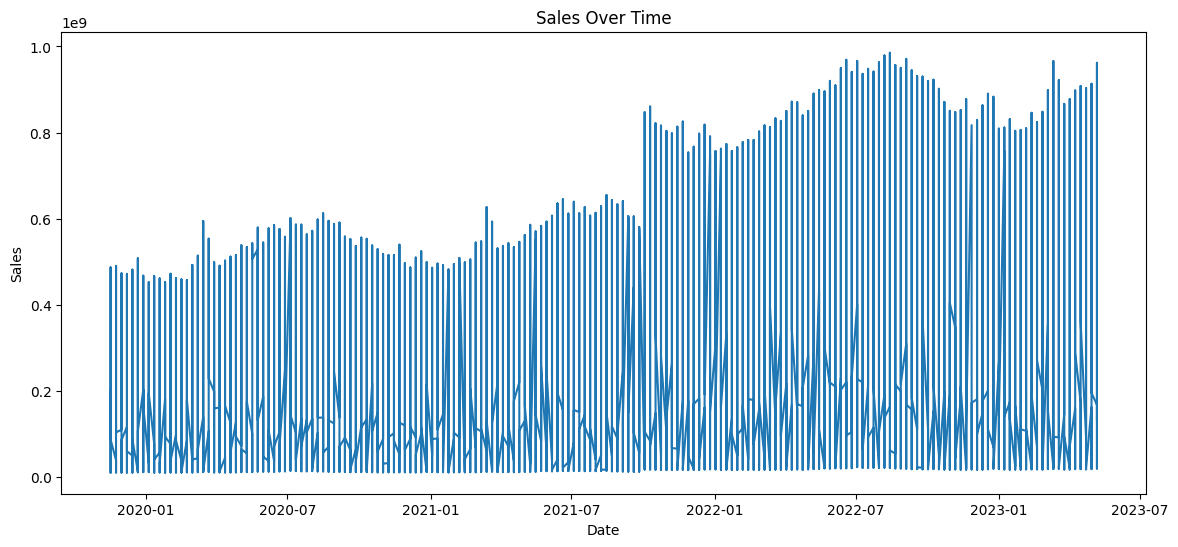

In [67]:
plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Total'])
plt.title('Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

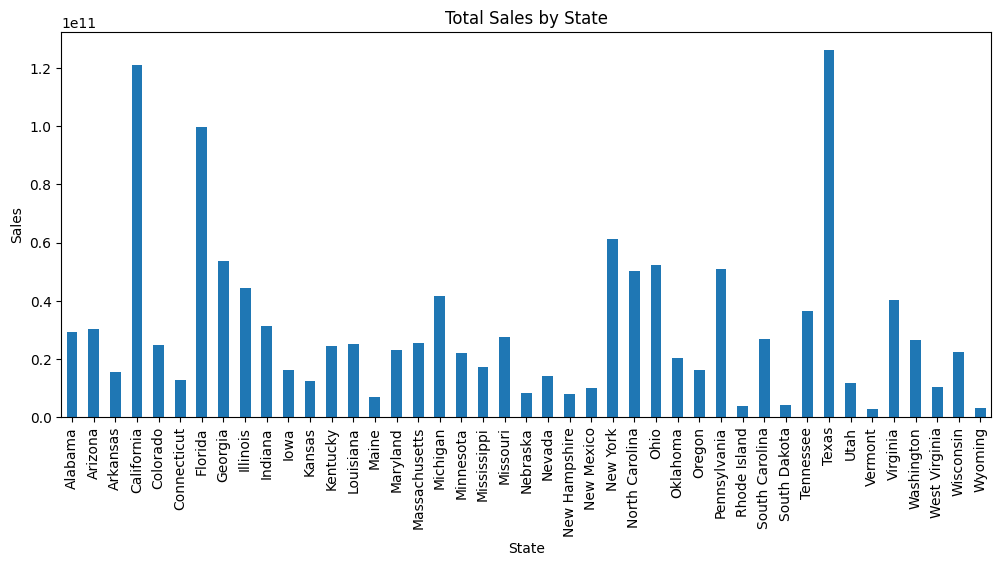

In [68]:
state_sales = df.groupby('State')['Total'].sum()

state_sales.plot(kind='bar', figsize=(12,5))
plt.title('Total Sales by State')
plt.ylabel('Sales')
plt.show()

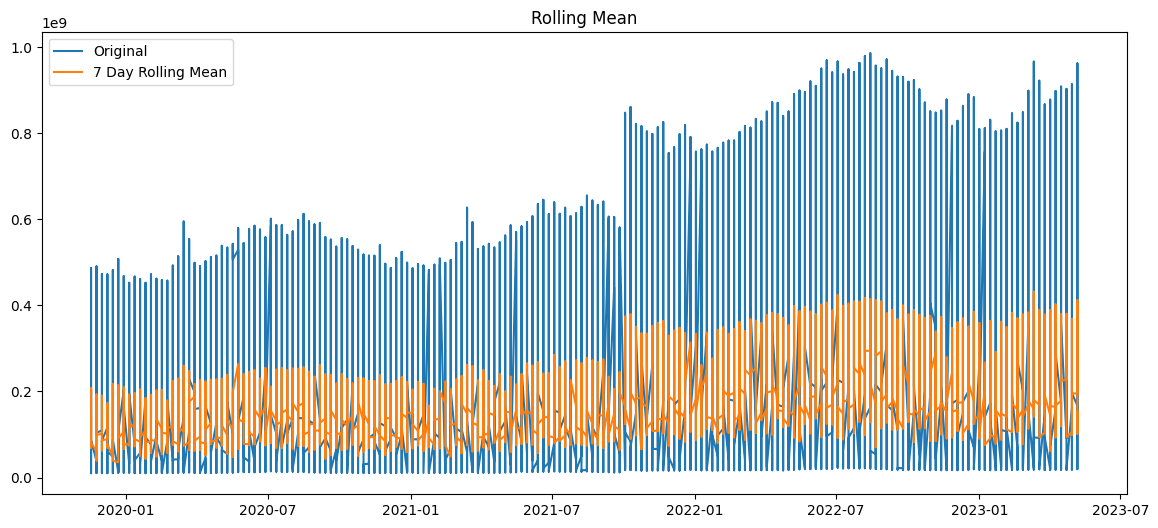

In [69]:
df['rolling_mean_7'] = df['Total'].rolling(7).mean()

plt.figure(figsize=(14,6))
plt.plot(df['Date'], df['Total'], label='Original')
plt.plot(df['Date'], df['rolling_mean_7'], label='7 Day Rolling Mean')
plt.legend()
plt.title('Rolling Mean')
plt.show()

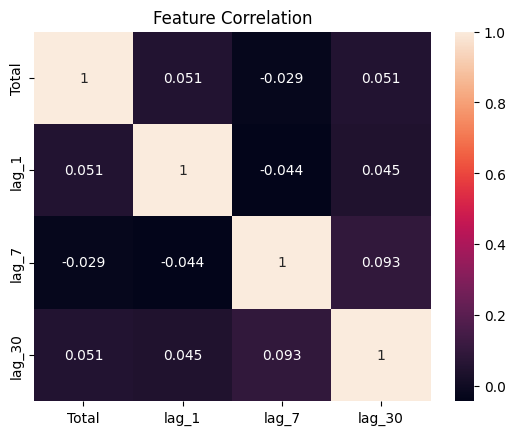

In [70]:
corr = df[['Total','lag_1','lag_7','lag_30']].corr()

sns.heatmap(corr, annot=True)
plt.title('Feature Correlation')
plt.show()

In [71]:
df.to_csv("../data/processed_sales_data.csv", index=False)